In [1]:
# Step 1: Import necessary libraries
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

# Step 2: Load the Iris dataset
iris = sns.load_dataset('iris')

# Step 3: Define predictors and target
X = iris[['sepal_width', 'petal_length', 'petal_width']]  # numeric predictors
y = iris['sepal_length']  # target

# Step 4: Create a pipeline with polynomial features + linear regression
# This makes it a polynomial regression model
polynomial_degree = 2  # Degree 2 = includes x² and interaction terms

model = Pipeline([
    ('poly_features', PolynomialFeatures(degree=polynomial_degree, include_bias=False)),
    ('scaler', StandardScaler()),  # scaling helps with polynomial features
    ('regressor', LinearRegression())
])

# Step 5: Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 6: Train the model
model.fit(X_train, y_train)

# Step 7: Predict
y_pred = model.predict(X_test)

# Step 8: Evaluate
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Polynomial Degree: {polynomial_degree}")
print("Mean Squared Error:", mse)
print("R^2 Score:", r2)

# Optional: Show number of features generated
poly_feature_names = model.named_steps['poly_features'].get_feature_names_out(X.columns)
print(f"\nOriginal features: {list(X.columns)}")
print(f"Polynomial features generated ({len(poly_feature_names)}):")
print(poly_feature_names)

Polynomial Degree: 2
Mean Squared Error: 0.10527870582313445
R^2 Score: 0.8474811099722797

Original features: ['sepal_width', 'petal_length', 'petal_width']
Polynomial features generated (9):
['sepal_width' 'petal_length' 'petal_width' 'sepal_width^2'
 'sepal_width petal_length' 'sepal_width petal_width' 'petal_length^2'
 'petal_length petal_width' 'petal_width^2']


Polynomial regression is linear regression on polynomial-expanded features. It captures nonlinear relationships by introducing terms like:
carat², carat * depth, x², etc.
We achieve this using PolynomialFeatures from sklearn.
🧠 Explanation in Code:
PolynomialFeatures(degree=2) generates all squared terms and interaction terms (e.g., carat^2, carat*depth).
We're still using LinearRegression, but it's trained on nonlinear features — that’s what makes this a polynomial regression model.

In [2]:
# Step 2: Load dataset
df = pd.read_csv("C:\\Users\\Somdip.Dey\\Desktop\\Regents_SWE6204\\diamonds.csv")  # or your own path
df.columns = df.columns.str.lower().str.strip()  # standardise column names

# Step 3: Select only numerical features (to simplify polynomial regression)
features = ['carat', 'depth', 'table', 'x', 'y', 'z']
X = df[features]
y = df['price']

# Step 4: Create pipeline with polynomial expansion and linear regression
# Polynomial regression works by applying PolynomialFeatures followed by LinearRegression
polynomial_degree = 2  # Degree 2 includes squares and pairwise interactions

pipeline = Pipeline([
    ('poly_features', PolynomialFeatures(degree=polynomial_degree, include_bias=False)),
    ('scaler', StandardScaler()),  # scale features for better numeric stability
    ('regressor', LinearRegression())
])

# Step 5: Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 6: Train the model
pipeline.fit(X_train, y_train)

# Step 7: Predict on test set
y_pred = pipeline.predict(X_test)

# Step 8: Evaluate
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Polynomial Degree: {polynomial_degree}")
print("Mean Squared Error:", mse)
print("R^2 Score:", r2)

# Optional: Show generated polynomial features
feature_names = pipeline.named_steps['poly_features'].get_feature_names_out(X.columns)
print(f"\nPolynomial features generated ({len(feature_names)}):")
print(feature_names)

Polynomial Degree: 2
Mean Squared Error: 1936009.4834721826
R^2 Score: 0.8782140511920526

Polynomial features generated (27):
['carat' 'depth' 'table' 'x' 'y' 'z' 'carat^2' 'carat depth' 'carat table'
 'carat x' 'carat y' 'carat z' 'depth^2' 'depth table' 'depth x' 'depth y'
 'depth z' 'table^2' 'table x' 'table y' 'table z' 'x^2' 'x y' 'x z' 'y^2'
 'y z' 'z^2']


Polynomial Regression using numpy polyfit method ->

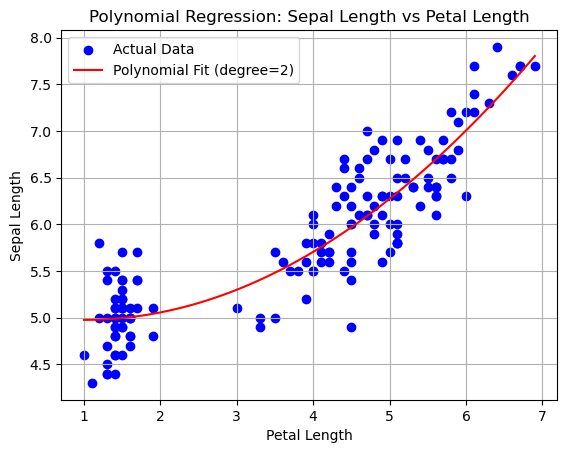

Polynomial Coefficients: [ 0.08146302 -0.16435073  5.05832761]
R² Score: 0.809473499553005


In [3]:
# Step 1: Import libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 2: Load the Iris dataset
iris = sns.load_dataset('iris')

# Step 3: Choose one feature and target
x = iris['petal_length'].values  # predictor
y = iris['sepal_length'].values  # target

# Step 4: Define polynomial degree
degree = 2  # Degree 2 = quadratic curve

# Step 5: Fit the polynomial regression model using numpy.polyfit
# This returns polynomial coefficients for: y = a*x^2 + b*x + c
coeffs = np.polyfit(x, y, deg=degree)

# Step 6: Create polynomial function from coefficients
poly_model = np.poly1d(coeffs)

# Step 7: Predict using the model
y_pred = poly_model(x)

# Step 8: Evaluate model (R²)
# Calculate R² manually
ss_total = np.sum((y - np.mean(y))**2)
ss_residual = np.sum((y - y_pred)**2)
r2 = 1 - (ss_residual / ss_total)

# Step 9: Plot the results
plt.scatter(x, y, color='blue', label='Actual Data')
x_line = np.linspace(x.min(), x.max(), 100)
y_line = poly_model(x_line)
plt.plot(x_line, y_line, color='red', label=f'Polynomial Fit (degree={degree})')
plt.xlabel('Petal Length')
plt.ylabel('Sepal Length')
plt.title('Polynomial Regression: Sepal Length vs Petal Length')
plt.legend()
plt.grid(True)
plt.show()

# Step 10: Print coefficients and R² score
print("Polynomial Coefficients:", coeffs)
print("R² Score:", r2)

🧠 Explanation: Why Is This Polynomial Regression?
np.polyfit(x, y, degree=2) fits a polynomial function of degree 2 to the data:
y=a⋅x2+b⋅x+c
This allows the model to capture curved relationships between the predictor and target, unlike simple linear regression which only fits a straight line.
The np.poly1d object lets you easily make predictions using that polynomial equation.